In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_curve, roc_auc_score

from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import GridSearchCV

from collections import Counter

# Load Dataset

In [ ]:
cols = ["target","id","date","flag","user","text"]
df = pd.read_csv("Sentiment140.csv", encoding="latin-1", names=cols)
df = df[["target","text"]]
df["target"] = df["target"].replace(4,1)
df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


# Data Cleaning

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

# EDA

In [4]:
df.info()
df.describe()
df["target"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   target      1600000 non-null  int64 
 1   text        1600000 non-null  object
 2   clean_text  1600000 non-null  object
dtypes: int64(1), object(2)
memory usage: 36.6+ MB


target
0    800000
1    800000
Name: count, dtype: int64

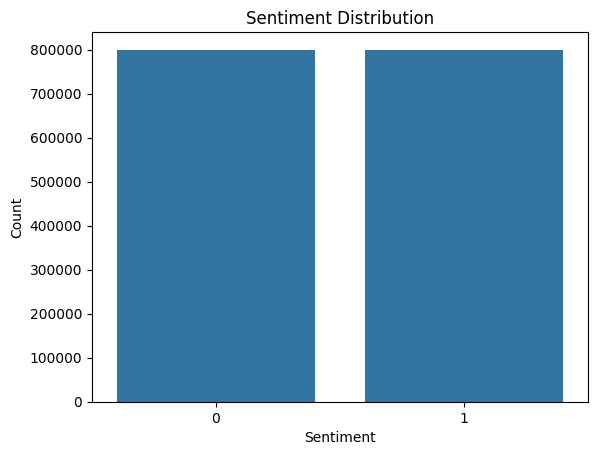

In [5]:
sns.countplot(x="target", data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

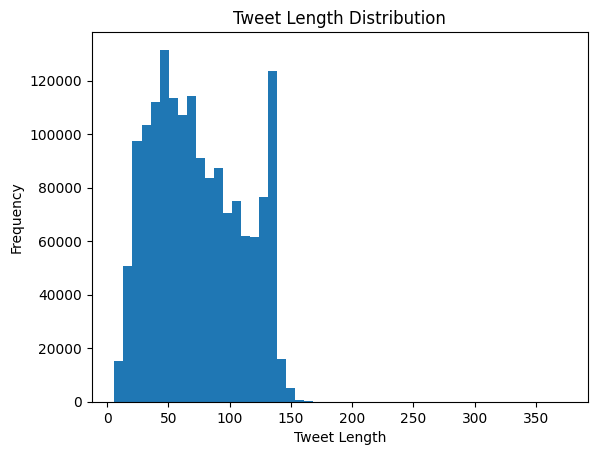

In [6]:
df["length"] = df["text"].apply(len)

plt.hist(df["length"], bins=50)

plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

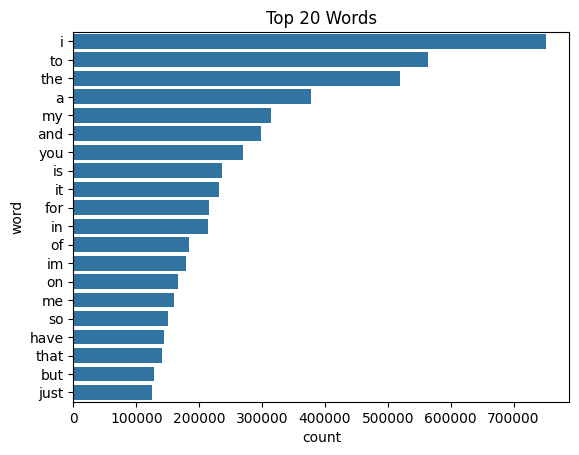

In [7]:
words = " ".join(df["clean_text"]).split()

freq = Counter(words).most_common(20)

freq_df = pd.DataFrame(freq, columns=["word","count"])

sns.barplot(x="count", y="word", data=freq_df)

plt.title("Top 20 Words")

plt.show()

In [8]:
!pip install wordcloud

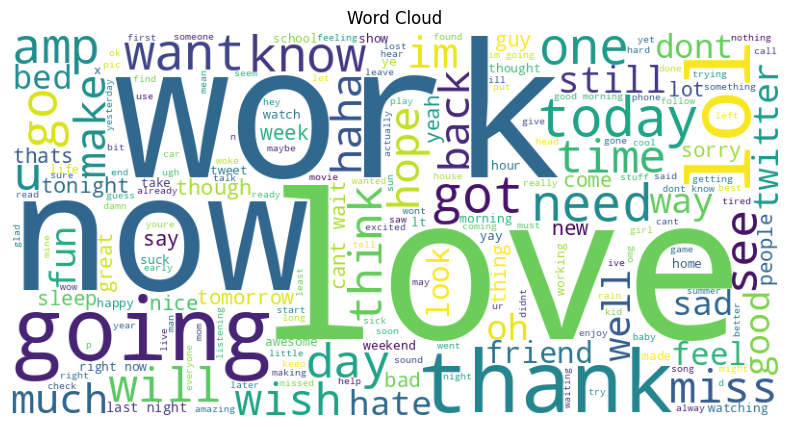

In [9]:
from wordcloud import WordCloud

text = " ".join(df["clean_text"])

wc = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")

plt.show()

# TF-IDF Feature Extraction

In [10]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_text"])

y = df["target"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = X_train[:20000]
y_train = y_train[:20000]

X_test = X_test[:5000]
y_test = y_test[:5000]

In [12]:
print(X_train.shape)
print(X_test.shape)

(20000, 5000)
(5000, 5000)


# KNN Model

In [13]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

print("Model created")

knn.fit(X_train, y_train)
print("Model trained")

y_pred_knn = knn.predict(X_test)
print("Prediction done")

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Model created
Model trained
Prediction done
Accuracy: 0.5504
F1 Score: 0.6031073446327684
              precision    recall  f1-score   support

           0       0.57      0.42      0.48      2496
           1       0.54      0.68      0.60      2504

    accuracy                           0.55      5000
   macro avg       0.55      0.55      0.54      5000
weighted avg       0.55      0.55      0.54      5000



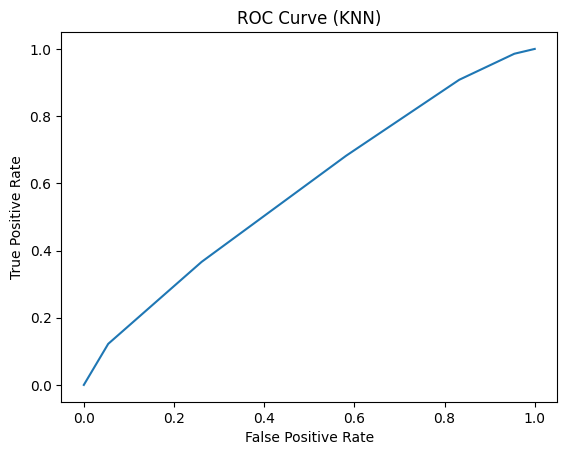

In [14]:
y_prob_knn = knn.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_knn)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve (KNN)")

plt.show()

# Naive Bayes Model

In [15]:
nb = MultinomialNB(alpha=1)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

Accuracy: 0.745
F1 Score: 0.7408009758080911


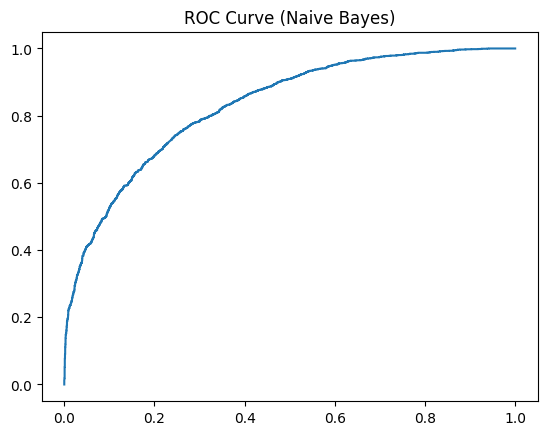

In [16]:
y_prob_nb = nb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_nb)

plt.plot(fpr, tpr)

plt.title("ROC Curve (Naive Bayes)")

plt.show()

# Dimensionality Reduction

In [17]:
svd = TruncatedSVD(n_components=50)
X_reduced = svd.fit_transform(X)

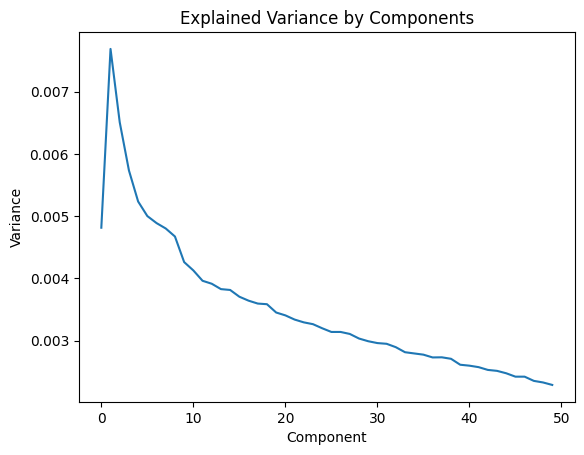

In [18]:
plt.plot(svd.explained_variance_ratio_)

plt.title("Explained Variance by Components")

plt.xlabel("Component")
plt.ylabel("Variance")

plt.show()

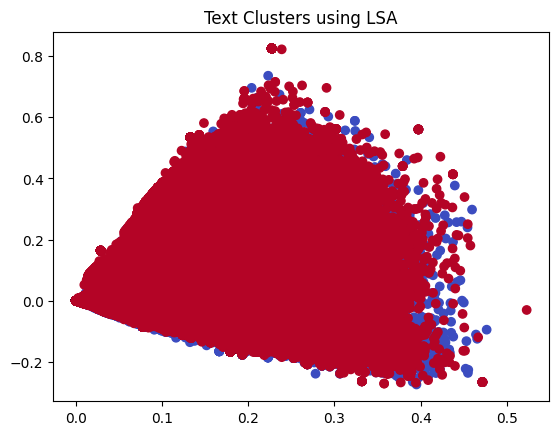

In [19]:
svd2 = TruncatedSVD(n_components=2)

X_vis = svd2.fit_transform(X)

plt.scatter(X_vis[:,0], X_vis[:,1], c=y, cmap="coolwarm")

plt.title("Text Clusters using LSA")

plt.show()

# Ensemble Models

In [20]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))

Accuracy: 0.7044


In [21]:
params = {"alpha":[0.01,0.1,1,10]}

grid = GridSearchCV(MultinomialNB(), params)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'alpha': 10}
